# 04 — Results & The Tipping Point Ranking

The core output of this project: a ranked list of occupations most likely to tip
from augmentation-dominant to automation-dominant AI use, along with analysis of
what drives these transitions.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.features import build_feature_matrix
from src.model import train_tipping_models, train_velocity_models, rank_tipping_candidates

sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams["figure.dpi"] = 150

COLORS = {"automation": "#E63946", "augmentation": "#457B9D", "accent": "#F4A261"}

In [2]:
features = build_feature_matrix()
tip_results = train_tipping_models(features)
vel_results = train_velocity_models(features)

best_clf = max(tip_results, key=lambda r: r.metrics["auc_cv_mean"])
best_vel = max(vel_results, key=lambda r: r.metrics["r2_cv_mean"])
print(f"Best classifier: {best_clf.name} (AUC = {best_clf.metrics['auc_cv_mean']:.3f})")
print(f"Best regressor: {best_vel.name} (R² = {best_vel.metrics['r2_cv_mean']:.3f})")

Best classifier: LogisticRegression (AUC = 0.765)
Best regressor: XGBoost (R² = 0.325)


## The Tipping Point Ranking

For occupations currently below 50% automation share, we rank them by predicted
probability of shifting toward automation. These are the occupations our model
identifies as most likely to cross the automation tipping point.

In [3]:
ranking = rank_tipping_candidates(features, best_clf)
print(f"Ranked {len(ranking)} augmentation-dominant occupations\n")
print("Top 30 occupations approaching the automation tipping point:")
print("=" * 95)
display_cols = ["title", "latest_automation_share", "predicted_automation_probability",
                "gap_to_tipping", "mediansalary"]
ranking[display_cols].head(30).style.format({
    "latest_automation_share": "{:.1%}",
    "predicted_automation_probability": "{:.1%}",
    "gap_to_tipping": "{:.1%}",
    "mediansalary": "${:,.0f}",
})

Ranked 606 augmentation-dominant occupations

Top 30 occupations approaching the automation tipping point:


,title,latest_automation_share,predicted_automation_probability,gap_to_tipping,mediansalary
0,Dancers,0.0%,100.0%,50.0%,$16
1,Singers,16.9%,99.8%,33.1%,$28
2,Public Address System and Other Announcers,0.0%,99.8%,50.0%,"$27,720"
3,Conveyor Operators and Tenders,30.6%,99.8%,19.4%,"$32,980"
4,Forest Fire Inspectors and Prevention Specialists,44.4%,99.8%,5.6%,"$39,600"
5,"Cutting and Slicing Machine Setters, Operators, and Tenders",0.0%,99.8%,50.0%,"$34,620"
6,Correctional Officers and Jailers,35.0%,99.6%,15.0%,"$44,330"
7,Amusement and Recreation Attendants,39.7%,99.6%,10.3%,"$22,260"
8,Photographic Process Workers and Processing Machine Operators,44.8%,99.6%,5.2%,"$29,180"
9,Fish and Game Wardens,0.0%,99.6%,50.0%,"$57,710"


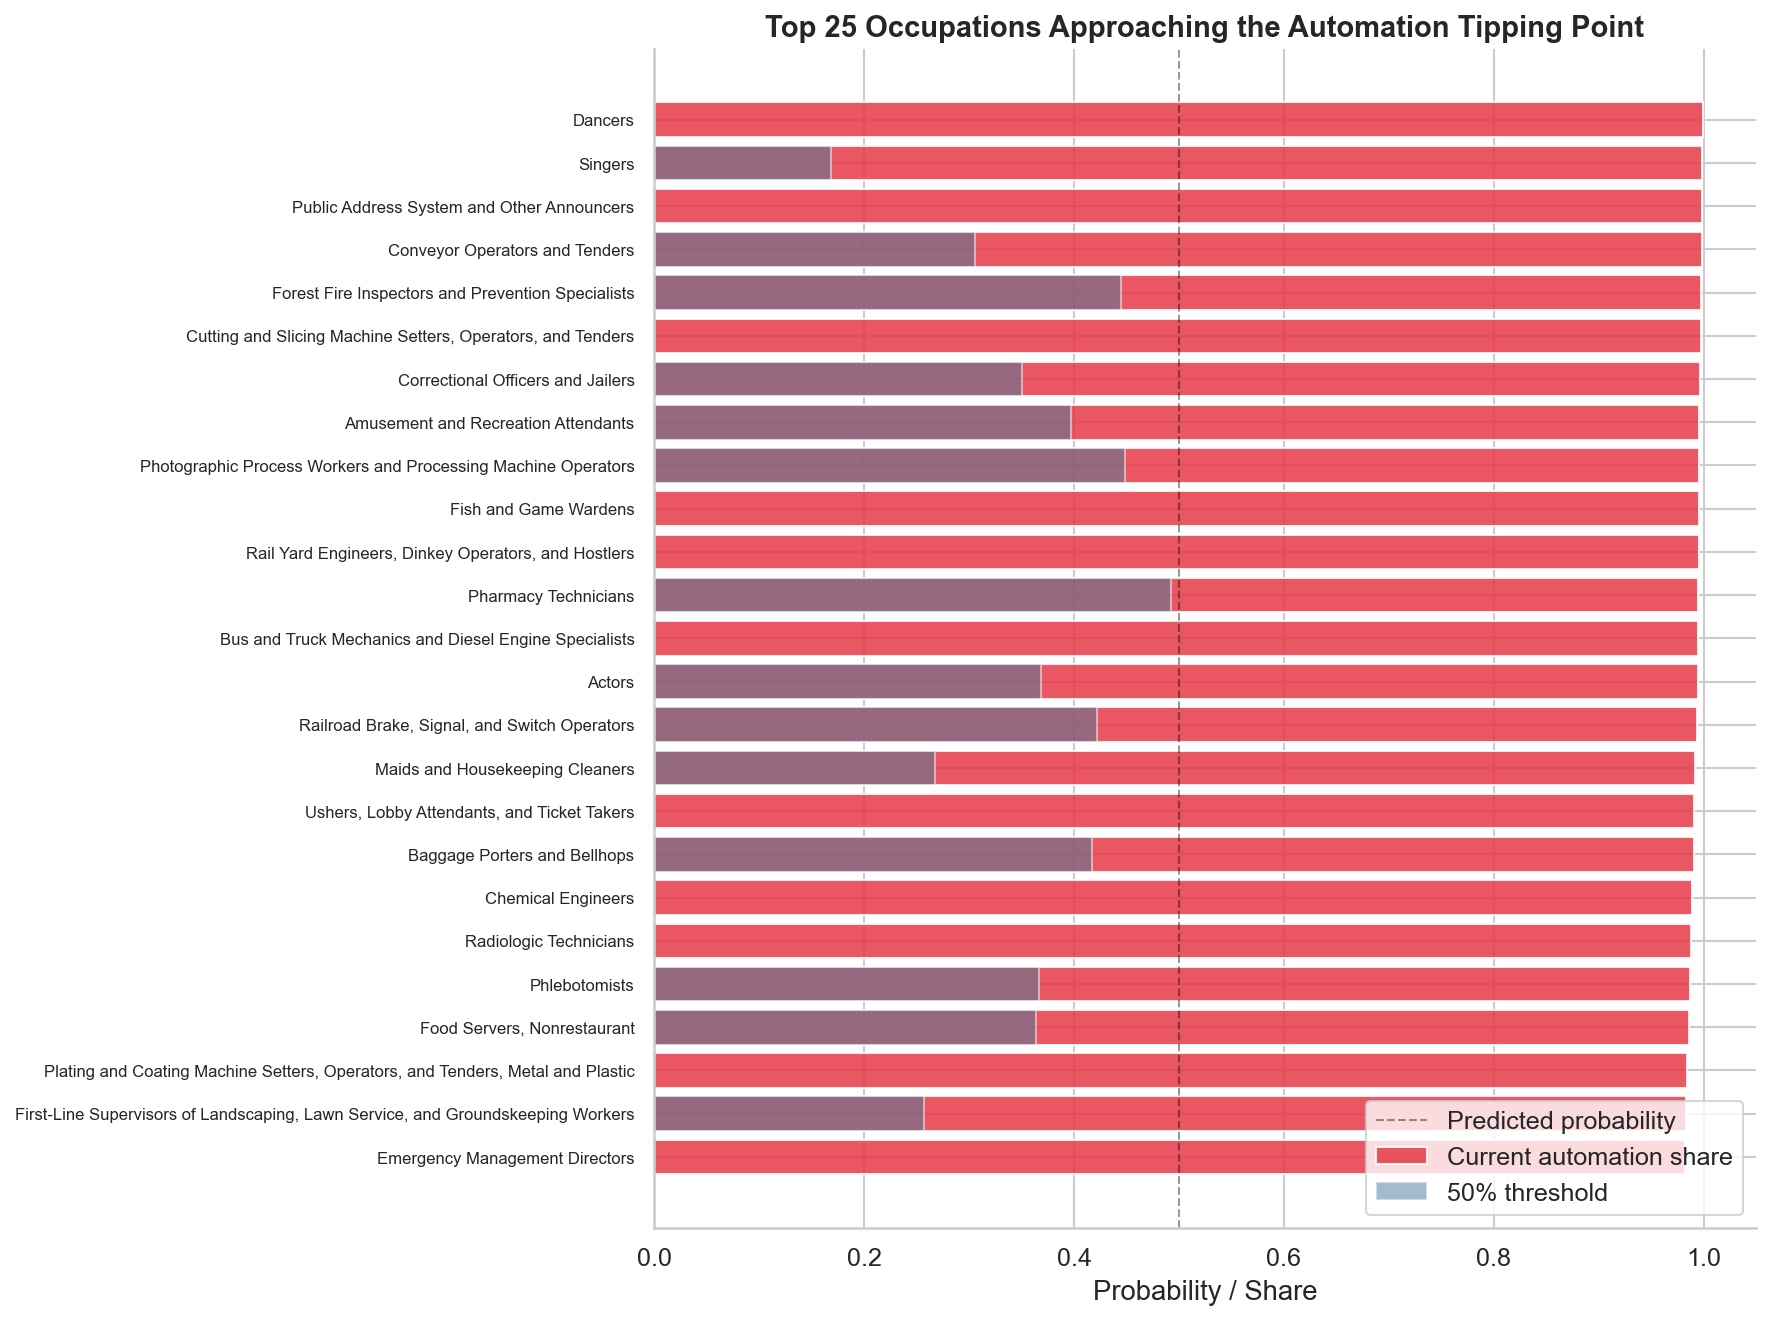

In [4]:
# Visualize the top candidates
top_n = 25
top = ranking.head(top_n).copy()

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(range(top_n), top["predicted_automation_probability"],
               color=COLORS["automation"], alpha=0.85, edgecolor="white")

# Overlay current automation share
ax.barh(range(top_n), top["latest_automation_share"],
        color=COLORS["augmentation"], alpha=0.5, edgecolor="white", label="Current automation share")

ax.set_yticks(range(top_n))
ax.set_yticklabels(top["title"].values, fontsize=8)
ax.set_xlabel("Probability / Share")
ax.set_title("Top 25 Occupations Approaching the Automation Tipping Point",
             fontsize=14, fontweight="bold")
ax.axvline(0.5, color="black", linestyle="--", linewidth=1, alpha=0.4, label="50% threshold")
ax.legend(loc="lower right", labels=["Predicted probability", "Current automation share", "50% threshold"])
ax.invert_yaxis()
sns.despine()
plt.tight_layout()
plt.savefig("../figures/13_tipping_point_ranking.png", bbox_inches="tight")
plt.show()

## Occupations that have already tipped

Which occupations started below 50% automation and crossed the threshold?

In [5]:
tipped = features[features["tipped"] == 1].copy()
tipped = tipped.sort_values("automation_delta", ascending=False)
print(f"{len(tipped)} occupations have tipped from augmentation to automation:\n")
tipped[["title", "initial_automation_share", "latest_automation_share",
        "automation_delta", "mediansalary"]].style.format({
    "initial_automation_share": "{:.1%}",
    "latest_automation_share": "{:.1%}",
    "automation_delta": "{:+.1%}",
    "mediansalary": "${:,.0f}",
})

21 occupations have tipped from augmentation to automation:



,title,initial_automation_share,latest_automation_share,automation_delta,mediansalary
497,Glaziers,0.0%,75.9%,+75.9%,"$43,550"
324,Occupational Health and Safety Specialists,0.0%,65.8%,+65.8%,"$73,020"
277,Orthodontists,0.0%,65.3%,+65.3%,"$208,000"
150,Geological Sample Test Technicians,13.3%,76.9%,+63.6%,"$53,300"
355,Animal Control Workers,0.0%,60.1%,+60.1%,"$36,330"
469,"Weighers, Measurers, Checkers, and Samplers, Recordkeeping",13.9%,68.1%,+54.2%,"$32,310"
333,Occupational Therapy Aides,0.0%,53.4%,+53.4%,"$28,160"
555,Timing Device Assemblers and Adjusters,0.0%,51.0%,+51.0%,"$34,650"
141,Urban and Regional Planners,7.8%,52.2%,+44.4%,"$73,050"
134,Remote Sensing Scientists and Technologists,28.5%,70.6%,+42.1%,"$107,230"


## What predicts the tipping point?

Comparing feature distributions between occupations that shifted toward automation
vs. those that shifted away.

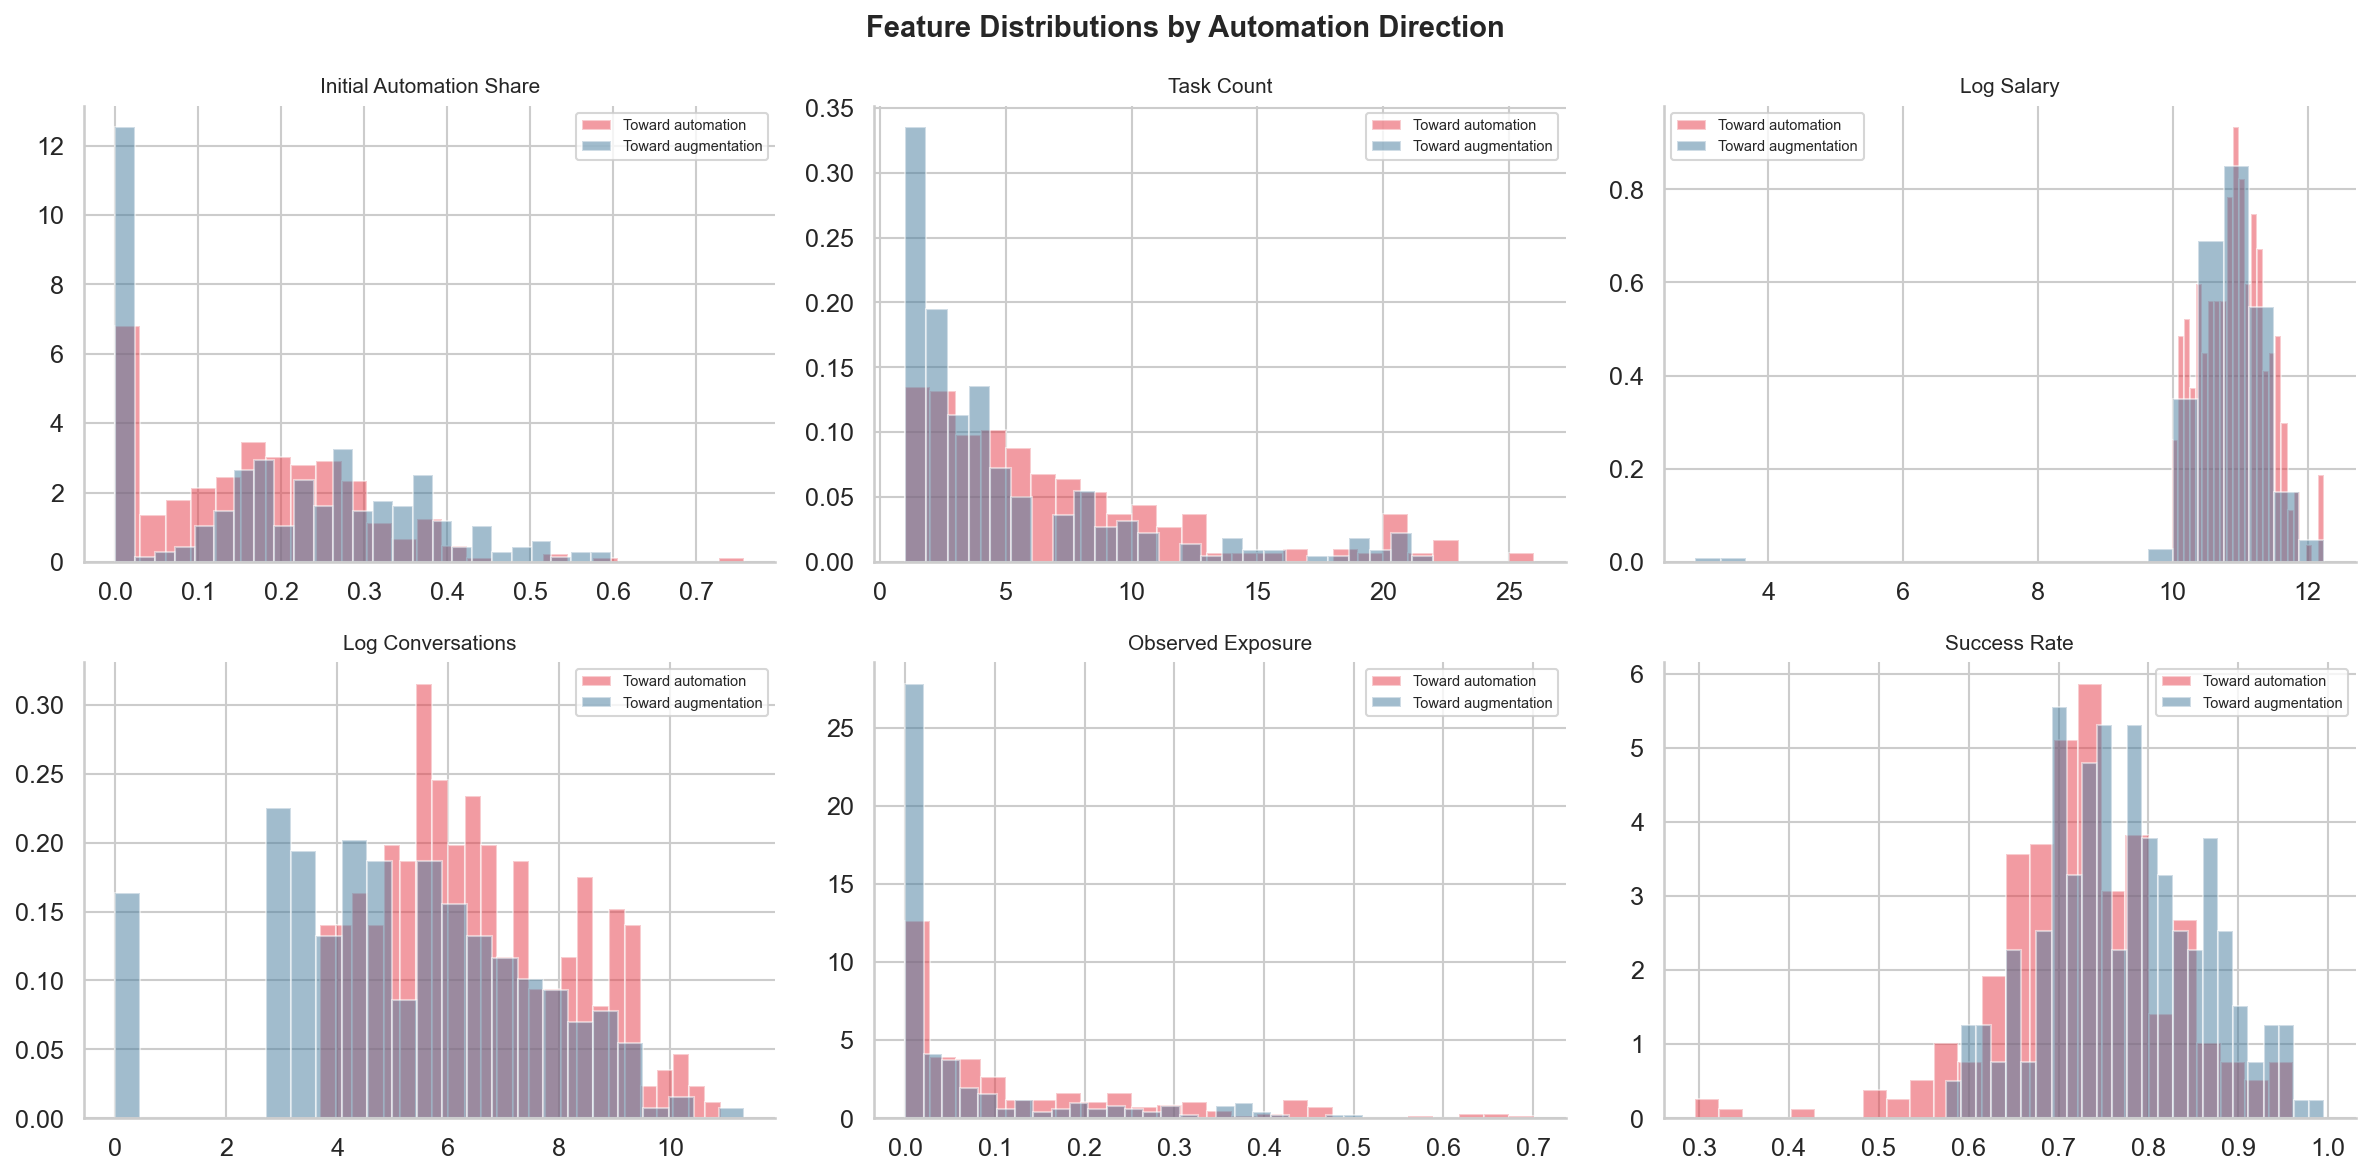

In [6]:
vel_df = features.dropna(subset=["automation_velocity"]).copy()
vel_df["direction"] = np.where(vel_df["automation_delta"] > 0,
                                "Toward automation", "Toward augmentation")

compare_features = ["initial_automation_share", "task_count", "log_salary",
                    "log_conversations", "observed_exposure", "success_rate"]
compare_features = [c for c in compare_features if c in vel_df.columns]

n_features = len(compare_features)
fig, axes = plt.subplots(2, (n_features + 1) // 2, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(compare_features):
    for direction, color in [("Toward automation", COLORS["automation"]),
                              ("Toward augmentation", COLORS["augmentation"])]:
        data = vel_df[vel_df["direction"] == direction][col].dropna()
        axes[i].hist(data, bins=25, alpha=0.5, color=color, label=direction, density=True)
    axes[i].set_title(col.replace("_", " ").title(), fontsize=10)
    axes[i].legend(fontsize=7)

# Hide unused axes
for j in range(n_features, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Feature Distributions by Automation Direction",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig("../figures/14_feature_distributions_by_direction.png", bbox_inches="tight")
plt.show()

## Automation frontier map by occupation group

How do different SOC major groups position on the automation spectrum?

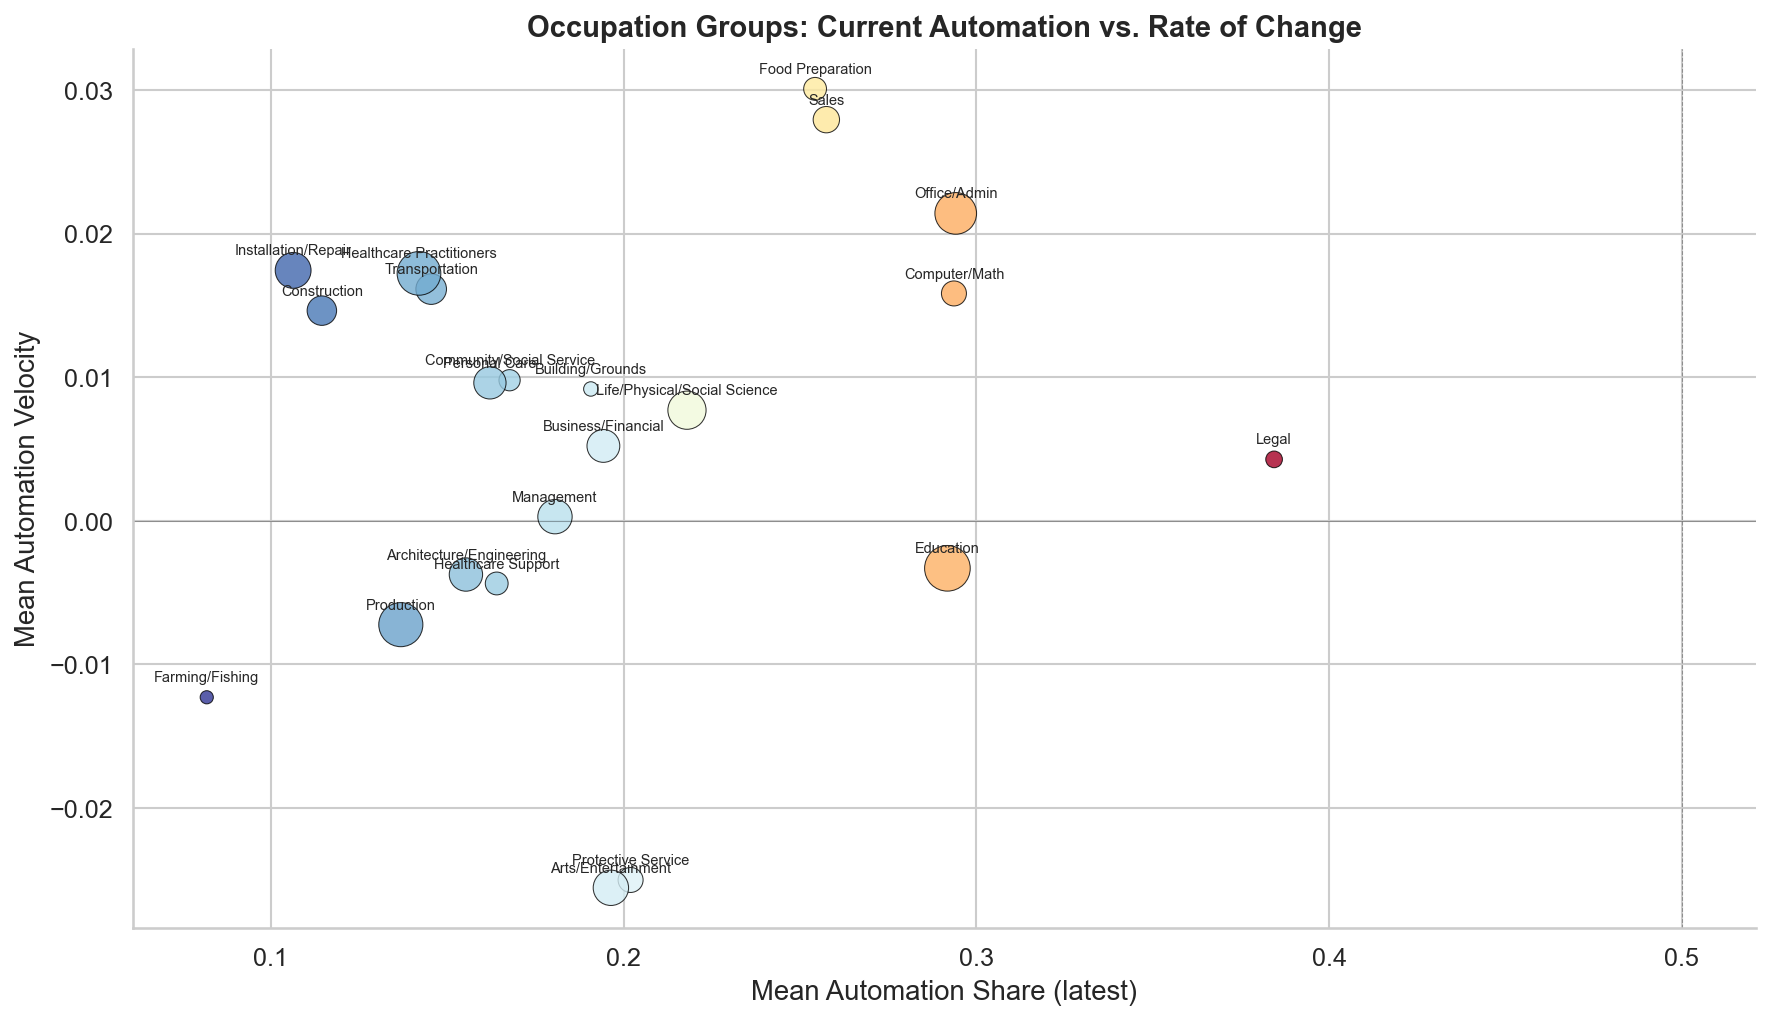

In [7]:
features["major_group"] = features["soc_code"].str[:2]
major_group_names = {
    "11": "Management", "13": "Business/Financial", "15": "Computer/Math",
    "17": "Architecture/Engineering", "19": "Life/Physical/Social Science",
    "21": "Community/Social Service", "23": "Legal", "25": "Education",
    "27": "Arts/Entertainment", "29": "Healthcare Practitioners",
    "31": "Healthcare Support", "33": "Protective Service",
    "35": "Food Preparation", "37": "Building/Grounds",
    "39": "Personal Care", "41": "Sales", "43": "Office/Admin",
    "45": "Farming/Fishing", "47": "Construction", "49": "Installation/Repair",
    "51": "Production", "53": "Transportation",
}
features["major_group_name"] = features["major_group"].map(major_group_names)

group_stats = (
    features.groupby("major_group_name")
    .agg(
        mean_automation=pd.NamedAgg("latest_automation_share", "mean"),
        mean_velocity=pd.NamedAgg("automation_velocity", "mean"),
        count=pd.NamedAgg("soc_code", "count"),
    )
    .dropna()
    .sort_values("mean_automation", ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(
    group_stats["mean_automation"],
    group_stats["mean_velocity"],
    s=group_stats["count"] * 8,
    c=group_stats["mean_automation"],
    cmap="RdYlBu_r",
    alpha=0.8,
    edgecolors="black",
    linewidth=0.5,
)

for name, row in group_stats.iterrows():
    ax.annotate(name, (row["mean_automation"], row["mean_velocity"]),
                fontsize=7, ha="center", va="bottom",
                xytext=(0, 6), textcoords="offset points")

ax.axhline(0, color="black", linestyle="-", linewidth=0.5, alpha=0.3)
ax.axvline(0.5, color="black", linestyle="--", linewidth=0.5, alpha=0.3)
ax.set_xlabel("Mean Automation Share (latest)")
ax.set_ylabel("Mean Automation Velocity")
ax.set_title("Occupation Groups: Current Automation vs. Rate of Change",
             fontsize=14, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.savefig("../figures/15_occupation_group_frontier.png", bbox_inches="tight")
plt.show()

## Summary statistics

In [8]:
print("Project Summary")
print("=" * 60)
print(f"Occupations analyzed:                  {len(features)}")
print(f"Occupations with temporal data:        {features['automation_velocity'].notna().sum()}")
print(f"Time periods covered:                  4 (Mar 2025 – Mar 2026)")
print(f"Currently automation-dominant (>50%):  {(features['latest_automation_share'] >= 0.5).sum()}")
print(f"Tipped during observation period:      {features['tipped'].sum()}")
print(f"")
print(f"Best velocity model:                   {best_vel.name} (R² = {best_vel.metrics['r2_cv_mean']:.3f})")
print(f"Best direction classifier:             {best_clf.name} (AUC = {best_clf.metrics['auc_cv_mean']:.3f})")
print(f"")
print(f"Top predictive features:")
for _, row in best_vel.feature_importance.head(5).iterrows():
    print(f"  {row['feature']:35s} {row['importance']:.3f}")

Project Summary
Occupations analyzed:                  633
Occupations with temporal data:        580
Time periods covered:                  4 (Mar 2025 – Mar 2026)
Currently automation-dominant (>50%):  27
Tipped during observation period:      21

Best velocity model:                   XGBoost (R² = 0.325)
Best direction classifier:             LogisticRegression (AUC = 0.765)

Top predictive features:
  log_conversations                   0.167
  initial_automation_share            0.122
  initial_directive                   0.121
  hhi                                 0.118
  success_rate                        0.077


---

**Key findings:**

1. **Conversation volume is the strongest predictor** of automation velocity — occupations with more AI usage are more likely to shift toward automation. This suggests a "deepening" dynamic where familiarity breeds automation.

2. **Initial automation share is highly predictive** — occupations that start closer to 50% are more likely to cross the threshold. The transition appears path-dependent.

3. **Wage is a weak predictor** — the frontier is genuinely "jagged." Low-wage and high-wage occupations both appear at the automation tipping point, challenging simple narratives about AI automating cheap labor first.

4. **Task success rate matters** — occupations where AI succeeds more often are more likely to shift toward automation, suggesting that demonstrated competence drives the augmentation → automation transition.

5. **21 occupations have already tipped** from augmentation to automation during our 12-month observation window, while ~600 remain augmentation-dominant.